# Neural Encoding Results — Visualization
Visualizes per-parcel Pearson r scores from `neural_encoding.py` for Ridge and Lasso models.

In [ ]:
import os
import json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import pearsonr

# ── Config ──────────────────────────────────────────────────────
RESULTS_FOLDER = "/scratch/arihantr/CSAI/results_encoding/"
MODELS         = ["ridge", "lasso"]
FEATURE_KEY    = "enc-last-ln" 
SUBJECT        = "sub-02"
ATLAS_PATH     = (
    "/scratch/arihantr/CSAI/algonauts_2025.competitors/fmri/sub-02/atlas/"
    "sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_"
    "parcel-1000Par7Net_desc-dseg_parcellation.nii.gz"
)

## 1. Load results

In [57]:
results = {}
for model in MODELS:
    r_path = os.path.join(RESULTS_FOLDER, SUBJECT, model, FEATURE_KEY, "pearson_r.npy")
    j_path = os.path.join(RESULTS_FOLDER, SUBJECT, model, FEATURE_KEY, "pearson_r.json")
    if not os.path.isfile(r_path):
        print(f"[SKIP] {r_path} not found")
        continue
    results[model] = {
        "r": np.load(r_path),
        "summary": json.load(open(j_path)),
    }
    s = results[model]["summary"]
    print(f"{model:10s}  mean r={s['mean_r']:.4f}  median r={s['median_r']:.4f}  "
          f"max r={s['max_r']:.4f}  %positive={s['pct_positive']:.1f}%")

ridge       mean r=0.0951  median r=0.0581  max r=0.4676  %positive=97.0%
[SKIP] /scratch/arihantr/CSAI/results_encoding/sub-01/lasso/enc-last-ln/pearson_r.npy not found


## 2. Per-parcel Pearson r distribution

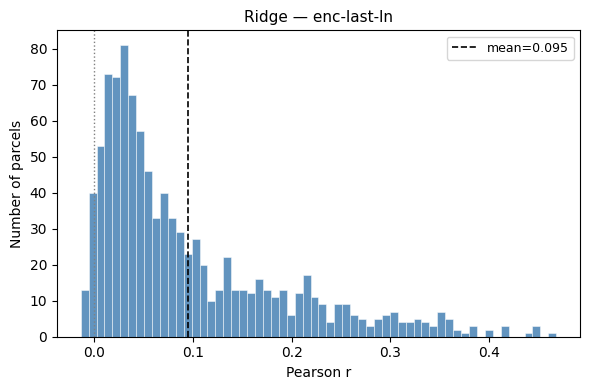

In [58]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 4), sharey=False)
if len(results) == 1:
    axes = [axes]

for ax, (model, data) in zip(axes, results.items()):
    r = data["r"]
    ax.hist(r, bins=60, color="steelblue" if model == "ridge" else "tomato",
            edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(np.mean(r), color="black", linestyle="--", linewidth=1.2, label=f"mean={np.mean(r):.3f}")
    ax.axvline(0, color="grey", linestyle=":", linewidth=1)
    ax.set_title(f"{model.capitalize()} — {FEATURE_KEY}", fontsize=11)
    ax.set_xlabel("Pearson r")
    ax.set_ylabel("Number of parcels")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, SUBJECT, "pearson_r_distribution.png"), dpi=150)
plt.show()

## 3. Ridge vs Lasso scatter

In [59]:
if "ridge" in results and "lasso" in results:
    r_ridge = results["ridge"]["r"]
    r_lasso = results["lasso"]["r"]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(r_ridge, r_lasso, s=4, alpha=0.4, color="mediumslateblue")
    lim = max(abs(r_ridge).max(), abs(r_lasso).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", linewidth=0.8, label="y=x")
    ax.axhline(0, color="grey", linewidth=0.5, linestyle=":")
    ax.axvline(0, color="grey", linewidth=0.5, linestyle=":")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("Ridge — Pearson r")
    ax.set_ylabel("Lasso — Pearson r")
    ax.set_title(f"Ridge vs Lasso per parcel ({SUBJECT})")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_FOLDER, SUBJECT, "ridge_vs_lasso_scatter.png"), dpi=150)
    plt.show()
else:
    print("Need both ridge and lasso results for this plot.")

Need both ridge and lasso results for this plot.


## 4. Top parcels bar chart

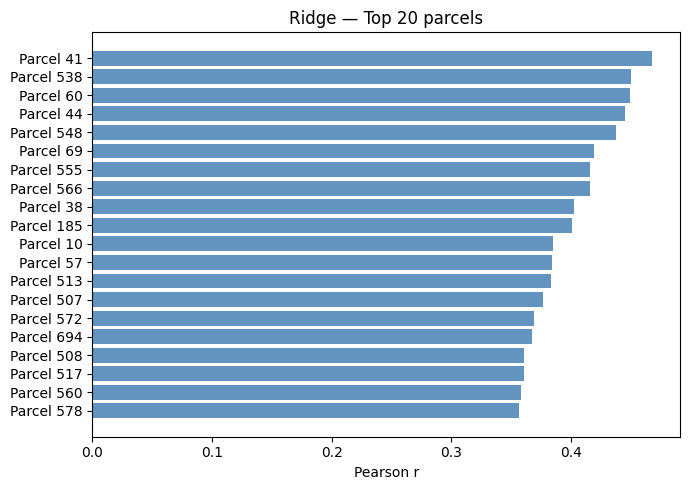

In [60]:
TOP_N = 20

fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (model, data) in zip(axes, results.items()):
    r = data["r"]
    top_idx = np.argsort(r)[::-1][:TOP_N]
    ax.barh(
        [f"Parcel {i}" for i in top_idx],
        r[top_idx],
        color="steelblue" if model == "ridge" else "tomato",
        alpha=0.85,
    )
    ax.set_xlabel("Pearson r")
    ax.set_title(f"{model.capitalize()} — Top {TOP_N} parcels")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, SUBJECT, "top_parcels.png"), dpi=150)
plt.show()

## 5. Brain map — project Pearson r back into 3D volume
Requires `nibabel`. Each parcel ID (1–1000) in the atlas gets its r value.

In [61]:
def parcels_to_volume(r_scores, atlas_path):
    """Map 1000-parcel r scores into the atlas 3D volume."""
    atlas_img = nib.load(atlas_path)
    atlas_data = atlas_img.get_fdata().astype(int)  # parcel IDs 1–1000, 0=background
    vol = np.zeros_like(atlas_data, dtype=float)
    for parcel_id in range(1, len(r_scores) + 1):
        mask = atlas_data == parcel_id
        vol[mask] = r_scores[parcel_id - 1]
    return nib.Nifti1Image(vol, atlas_img.affine)


def plot_brain_slices(nifti_img, title, vmax=None, cmap="RdBu_r"):
    data = nifti_img.get_fdata()
    vmax = vmax or np.percentile(np.abs(data[data != 0]), 95)
    vmin = -vmax

    slices = {
        "Axial (z)": data[:, :, data.shape[2] // 2],
        "Coronal (y)": data[:, data.shape[1] // 2, :],
        "Sagittal (x)": data[data.shape[0] // 2, :, :],
    }

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (label, sl) in zip(axes, slices.items()):
        im = ax.imshow(sl.T, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(label)
        ax.axis("off")
    fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label="Pearson r")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    save_name = title.lower().replace(" ", "_").replace("—", "").replace("(", "").replace(")", "") + ".png"
    plt.savefig(os.path.join(RESULTS_FOLDER, SUBJECT, save_name), dpi=150)
    plt.show()


if os.path.isfile(ATLAS_PATH):
    for model, data in results.items():
        brain_img = parcels_to_volume(data["r"], ATLAS_PATH)
        nib.save(brain_img, os.path.join(RESULTS_FOLDER, SUBJECT, f"{model}_{FEATURE_KEY}_pearson_r.nii.gz"))
        plot_brain_slices(brain_img, title=f"{model.capitalize()} Pearson r — {SUBJECT}")
else:
    print(f"Atlas not found at {ATLAS_PATH} — skipping brain map.")
    print("Make sure you ran: datalad get fmri/sub-05/atlas/")

Atlas not found at /scratch/arihantr/CSAI/algonauts_2025.competitors/fmri/sub-01/atlas/sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz — skipping brain map.
Make sure you ran: datalad get fmri/sub-05/atlas/


## 6. Summary table

In [62]:
print(f"{'Model':<10} {'Mean r':>8} {'Median r':>9} {'Max r':>7} {'% positive':>11}")
print("-" * 50)
for model, data in results.items():
    s = data["summary"]
    print(f"{model:<10} {s['mean_r']:>8.4f} {s['median_r']:>9.4f} {s['max_r']:>7.4f} {s['pct_positive']:>10.1f}%")

Model        Mean r  Median r   Max r  % positive
--------------------------------------------------
ridge        0.0951    0.0581  0.4676       97.0%
